# Projeto: IMPACTO DOS CRUZAMENTOS DE ESTRADAS SOBRE A CONECTIVIDADE ECOHIDROLÓGICA DE IGARAPÉS AMAZÔNICOS EM PAISAGENS SOB DESMATAMENTO

Autor Principal/Contato Principal: Gabriel Oliveira Ferraz / gabriel.oferraz@usp.br

Autores: FERRAZ, G.O.; LEAL, C.G.; CORREA, K.A.B.; COUTO, T.B.D'A.; MAEOKA, L.T.Y.; BREJAO, G.L.; CARVALHO, D.R.; ALVES FILHO, M.A.; BARLOW, J.; FERRAZ, S.F.B.

# **Parte 1** - Configuração do sistema

In [1]:
%%capture
!pip install geopandas rasterio pandas fiona

In [2]:
# =========================================================
# EXPRESSÕES REGULARES E ESTRUTURAS AUXILIARES
# =========================================================
import re
from collections import defaultdict
from io import StringIO

# =========================================================
# SISTEMA / IO
# =========================================================
import glob
import os

# =========================================================
# REDE / DOWNLOAD
# =========================================================
import requests

# =========================================================
# DADOS TABULARES / NUMÉRICOS
# =========================================================
import numpy as np
import pandas as pd

# =========================================================
# GEOPROCESSAMENTO VETORIAL
# =========================================================
import fiona
import geopandas as gpd
from shapely.geometry import Point, box
from shapely.geometry import box, shape

# =========================================================
# PROCESSAMENTO RASTER
# =========================================================
import rasterio
from rasterio.features import geometry_mask
from rasterio.mask import mask
from rasterio.features import sieve
from rasterio.warp import Resampling, reproject

# =========================================================
# VISUALIZAÇÃO
# =========================================================
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# =========================================================
# AMBIENTE COLAB
# =========================================================
try:
    from google.colab import drive
except ImportError:
    drive = None

In [3]:
# Criar um mapeamento entre valores de classe e seus rótulos e cores correspondentes
class_info = {
    3: {'label': 'Formação Florestal', 'color': '#006400'},
    4: {'label': 'Formação Savânica', 'color': '#00ff00'},
    5: {'label': 'Mangue', 'color': '#687537'},
    49: {'label': 'Restinga Arborizada', 'color': '#6b9932'},
    11: {'label': 'Campo Alagado e Área Pantanosa', 'color': '#45c2a5'},
    12: {'label': 'Formação Campestre', 'color': '#b8af4f'},
    32: {'label': 'Apicum', 'color': '#968c46'},
    29: {'label': 'Afloramento Rochoso', 'color': '#ff8C00'},
    50: {'label': 'Restinga Herbácea', 'color': '#66ffcc'},
    13: {'label': 'Outras Formações não Florestais', 'color': '#bdb76b'},
    15: {'label': 'Pastagem', 'color': '#ffd966'},
    18: {'label': 'Agricultura', 'color': '#e974ed'},
    19: {'label': 'Lavoura Temporária', 'color': '#d5a6bd'},
    39: {'label': 'Soja', 'color': '#c59ff4'},
    20: {'label': 'Cana', 'color': '#c27ba0'},
    40: {'label': 'Arroz', 'color': '#982c9e'},
    62: {'label': 'Algodão', 'color': '#660066'},
    41: {'label': 'Outras Lavouras Temporárias', 'color': '#e787f8'},
    36: {'label': 'Lavoura Perene', 'color': '#f3b4f1'},
    46: {'label': 'Café', 'color': '#cca0d4'},
    47: {'label': 'Citrus', 'color': '#d082de'},
    48: {'label': 'Outras Lavouras Perenes', 'color': '#cd49e4'},
    9: {'label': 'Silvicultura', 'color': '#935132'},
    21: {'label': 'Mosaico de Usos', 'color': '#fff3bf'},
    23: {'label': 'Praia, Duna e Areal', 'color': '#dd7e6b'},
    24: {'label': 'Área Urbanizada', 'color': '#af2a2a'},
    30: {'label': 'Mineração', 'color': '#8a2be2'},
    25: {'label': 'Outras Áreas não Vegetadas', 'color': '#ff99ff'},
    33: {'label': 'Rio, Lago e Oceano', 'color': '#0000ff'},
    31: {'label': 'Aquicultura', 'color': '#29eee4'},
    27: {'label': 'Não observado', 'color': '#D5D5E5'},
}

In [4]:
def obter_shapefiles_municipios(codigos_mun) -> gpd.GeoDataFrame:
    """
    Obtém as malhas de um ou mais municípios diretamente da API de malhas do IBGE.

    Caso uma lista de códigos seja fornecida, a função baixa cada município e os
    concatena em um único GeoDataFrame.

    Parameters
    ----------
    codigos_mun : str ou list
        Código(s) IBGE do município com 7 dígitos (ex: '1505502' para Paragominas).

    Returns
    -------
    geopandas.GeoDataFrame
        GeoDataFrame contendo a(s) geometria(s) do(s) município(s).

    Raises
    ------
    ValueError
        Se algum código do município não possuir 7 caracteres.
    RuntimeError
        Se nenhum município puder ser lido.
    """
    if isinstance(codigos_mun, str):
        codigos_mun = [codigos_mun]

    gdfs_municipios = []

    for cod in codigos_mun:
        cod = str(cod).strip()
        if len(cod) != 7:
            raise ValueError(f"O código '{cod}' não possui 7 caracteres.")

        url = f"https://servicodados.ibge.gov.br/api/v3/malhas/municipios/{cod}?formato=application/vnd.geo+json"

        try:
            response = requests.get(url, timeout=60)
            response.raise_for_status()

            municipio_gdf = gpd.read_file(StringIO(response.text))

            if 'codarea' not in municipio_gdf.columns:
                municipio_gdf['codarea'] = cod

            gdfs_municipios.append(municipio_gdf)

        except Exception as exc:
            print(f"⚠️ Não foi possível baixar/ler a malha do município '{cod}': {exc}")

    if not gdfs_municipios:
        raise RuntimeError("Nenhum shapefile municipal pôde ser obtido da API do IBGE.")

    # Concatena todos os municípios em um único arquivo
    gdf_final = gpd.GeoDataFrame(pd.concat(gdfs_municipios, ignore_index=True), crs=gdfs_municipios[0].crs)
    return gdf_final


def download_mapbiomas(
    output_dir: str = "/content/mapbiomas_completo/",
    ano_inicio: int = 1985,
    ano_fim: int = 2024,
    base_url: str = "https://storage.googleapis.com/mapbiomas-public/initiatives/brasil/collection_10/lulc/coverage/"
) -> None:
    """
    Realiza o download dos rasters anuais de cobertura e uso da terra do MapBiomas.

    A função baixa os arquivos GeoTIFF da Coleção 10 do MapBiomas para um diretório local,
    seguindo o padrão de nomenclatura:
    `brazil_coverage_{ano}.tif`.

    Parameters
    ----------
    output_dir : str, default "/content/mapbiomas_completo/"
        Diretório de saída onde os arquivos serão armazenados.
    ano_inicio : int, default 1985
        Ano inicial do intervalo de download.
    ano_fim : int, default 2024
        Ano final do intervalo de download.
    base_url : str
        URL base do repositório público do MapBiomas Coleção 10.

    Returns
    -------
    None

    Raises
    ------
    ValueError
        Se o intervalo de anos for inválido.

    Notes
    -----
    - Os arquivos são baixados de um bucket público do Google Storage.
    - O download é feito de forma sequencial, ano a ano.
    - Esta função não implementa retentativa automática nem verificação de integridade do arquivo.
    """
    if ano_inicio > ano_fim:
        raise ValueError("'ano_inicio' não pode ser maior que 'ano_fim'.")

    os.makedirs(output_dir, exist_ok=True)

    for ano in range(ano_inicio, ano_fim + 1):
        file_name = f"brazil_coverage_{ano}.tif"
        url = base_url + file_name
        output_path = os.path.join(output_dir, file_name)

        try:
            response = requests.get(url, timeout=60)

            if response.status_code == 200:
                with open(output_path, "wb") as f:
                    f.write(response.content)
                print(f"✅ Arquivo baixado com sucesso: {file_name}")
            else:
                print(f"❌ Erro no download de {file_name} | HTTP {response.status_code}")

        except requests.RequestException as exc:
            print(f"⚠️ Falha de conexão ao baixar {file_name}: {exc}")

    print("\nDownload concluído.")


def download_file(url: str, save_path: str) -> None:
    """
    Faz o download de um arquivo remoto e salva localmente em disco.

    O download é realizado em modo streaming, reduzindo o consumo de memória
    ao gravar o conteúdo em blocos (`chunks`).

    Parameters
    ----------
    url : str
        URL completa do arquivo a ser baixado.
    save_path : str
        Caminho completo de saída, incluindo nome do arquivo.

    Returns
    -------
    None

    Raises
    ------
    ValueError
        Se a URL ou o caminho de saída forem inválidos.

    Notes
    -----
    - O diretório de destino é criado automaticamente caso não exista.
    - O tamanho do chunk está configurado em 8192 bytes.
    - Esta função não verifica checksum, hash ou tamanho final do arquivo.
    """
    if not isinstance(url, str) or not url.strip():
        raise ValueError("O parâmetro 'url' deve ser uma string não vazia.")

    if not isinstance(save_path, str) or not save_path.strip():
        raise ValueError("O parâmetro 'save_path' deve ser uma string não vazia.")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    try:
        response = requests.get(url, stream=True, timeout=60)
        response.raise_for_status()

        with open(save_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    file.write(chunk)

        print(f"✅ Arquivo baixado com sucesso em: {save_path}")

    except requests.RequestException as exc:
        print(f"❌ Falha ao baixar o arquivo: {exc}")


def crop_raster_by_municipality(
    shapefile_path: str,
    raster_path: str,
    output_dir: str,
    municipio: str
) -> str:
    """
    Recorta um raster utilizando a geometria de um município específico.

    A função lê um arquivo vetorial contendo municípios, localiza a feição
    cujo atributo `NM_MUN` corresponda ao nome informado, e usa essa geometria
    para recortar um raster via `rasterio.mask.mask`.

    Parameters
    ----------
    shapefile_path : str
        Caminho para o arquivo vetorial contendo os municípios.
    raster_path : str
        Caminho para o raster a ser recortado.
    output_dir : str
        Diretório onde o raster recortado será salvo.
    municipio : str
        Nome do município exatamente como registrado no atributo `NM_MUN`.

    Returns
    -------
    str
        Caminho completo do raster recortado gerado.

    Raises
    ------
    FileNotFoundError
        Se o shapefile ou o raster não forem encontrados.
    ValueError
        Se o município não existir no arquivo vetorial.

    Notes
    -----
    - A função assume a existência do campo `NM_MUN` na tabela de atributos.
    - Não é realizada reprojeção automática entre shapefile e raster.
      Portanto, ambos devem estar no mesmo SRC/CRS.
    - O nome do arquivo de saída recebe o sufixo `_masked`.
    """
    if not os.path.exists(shapefile_path):
        raise FileNotFoundError(f"Shapefile não encontrado: {shapefile_path}")

    if not os.path.exists(raster_path):
        raise FileNotFoundError(f"Raster não encontrado: {raster_path}")

    os.makedirs(output_dir, exist_ok=True)

    raster_name = os.path.basename(raster_path).replace(".tif", "")
    output_raster_path = os.path.join(
        output_dir,
        f"{raster_name}_{municipio}_masked.tif"
    )

    with fiona.open(shapefile_path, "r") as shapefile:
        municipio_geom = [
            feature["geometry"]
            for feature in shapefile
            if feature["properties"]["NM_MUN"] == municipio
        ]

    if not municipio_geom:
        raise ValueError(f"O município '{municipio}' não foi encontrado no shapefile.")

    with rasterio.open(raster_path) as src:
        out_image, out_transform = mask(src, municipio_geom, crop=True)
        out_meta = src.meta.copy()

    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform,
    })

    with rasterio.open(output_raster_path, "w", **out_meta) as dest:
        dest.write(out_image)

    print(f"✅ Raster recortado salvo em: {output_raster_path}")
    return output_raster_path


def recortar_mapbiomas_por_roi(
    gdf_shapefile: gpd.GeoDataFrame,
    input_dir: str = "/content/mapbiomas_completo/",
    output_dir: str = "/content/ROI/",
    ano_inicio: int = 1985,
    ano_fim: int = 2024,
    margem: float = 0.008,
    plotar: bool = True
) -> None:
    """
    Recorta os rasters anuais do MapBiomas com base no retângulo envolvente
    (bounding box expandido) de uma região de interesse.

    A função calcula o envelope espacial do `GeoDataFrame` de entrada,
    aplica uma margem adicional em unidades do CRS, cria um polígono retangular
    e recorta cada raster anual do intervalo especificado.

    Parameters
    ----------
    gdf_shapefile : geopandas.GeoDataFrame
        GeoDataFrame contendo a região de interesse (ROI).
    input_dir : str, default "/content/mapbiomas_completo/"
        Diretório onde estão armazenados os rasters anuais originais.
    output_dir : str, default "/content/ROI/"
        Diretório de saída para os rasters recortados.
    ano_inicio : int, default 1985
        Ano inicial do processamento.
    ano_fim : int, default 2024
        Ano final do processamento.
    margem : float, default 0.008
        Valor adicional aplicado aos limites do bounding box.
        A interpretação depende do CRS do `gdf_shapefile`. Em CRS geográfico,
        normalmente representa graus.
    plotar : bool, default True
        Se `True`, plota a ROI original e o bounding box expandido.

    Returns
    -------
    None

    Raises
    ------
    ValueError
        Se o GeoDataFrame estiver vazio ou o intervalo de anos for inválido.

    Notes
    -----
    - O recorte é feito sobre o bounding box expandido, e não sobre a geometria
      original detalhada da ROI.
    - Se a projeção da ROI diferir do raster, o bounding box será reprojetado
      para garantir o cruzamento correto.
    - Os arquivos de saída seguem o padrão: `mb-brazil-v10-{ano}.tif`.
    """
    if gdf_shapefile is None or gdf_shapefile.empty:
        raise ValueError("O 'gdf_shapefile' está vazio ou inválido.")

    if ano_inicio > ano_fim:
        raise ValueError("'ano_inicio' não pode ser maior que 'ano_fim'.")

    os.makedirs(output_dir, exist_ok=True)

    extensao = gdf_shapefile.total_bounds

    minx = extensao[0] - margem
    miny = extensao[1] - margem
    maxx = extensao[2] + margem
    maxy = extensao[3] + margem

    quadrado_geom = box(minx, miny, maxx, maxy)

    gdf_quadrado = gpd.GeoDataFrame(
        geometry=[quadrado_geom],
        crs=gdf_shapefile.crs
    )

    if plotar:
        ax = gdf_shapefile.plot(edgecolor="red", facecolor="none", figsize=(10, 10))
        gdf_quadrado.plot(ax=ax, edgecolor="blue", facecolor="none")
        plt.show()

    for ano in range(ano_inicio, ano_fim + 1):
        file_name = f"brazil_coverage_{ano}.tif"
        input_path = os.path.join(input_dir, file_name)

        if not os.path.exists(input_path):
            print(f"⚠️ Arquivo não encontrado: {file_name}")
            continue

        with rasterio.open(input_path) as src:
            # --- CORREÇÃO DE CRS ---
            # Garante que a geometria de recorte use o mesmo sistema de coordenadas do raster
            if gdf_quadrado.crs != src.crs:
                geom_recorte = gdf_quadrado.to_crs(src.crs).geometry
            else:
                geom_recorte = gdf_quadrado.geometry

            out_image, out_transform = mask(
                src,
                geom_recorte,
                crop=True
            )

            out_meta = src.meta.copy()
            out_meta.update({
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })

            output_path = os.path.join(output_dir, f"mb-brazil-v10-{ano}.tif")

            with rasterio.open(output_path, "w", **out_meta) as dest:
                dest.write(out_image)

        print(f"✅ Raster recortado com sucesso: {output_path}")

    print("\nProcesso concluído.")


def contar_ocorrencias_classe_rasters(
    input_folder: str,
    output_raster: str,
    classe: int = 33
):
    """
    Calcula a contagem acumulada de ocorrência de uma classe específica
    ao longo de múltiplos rasters anuais.

    Para cada pixel, a função soma o número de vezes em que o valor do pixel
    é igual à classe especificada em todos os rasters da pasta.

    Parameters
    ----------
    input_folder : str
        Caminho para a pasta contendo os rasters (.tif).
    output_raster : str
        Caminho completo do raster de saída.
    classe : int, default 33
        Valor da classe a ser contabilizada.

    Returns
    -------
    numpy.ndarray
        Matriz 2D contendo a contagem acumulada por pixel.

    Raises
    ------
    FileNotFoundError
        Se a pasta não existir ou não contiver arquivos .tif.
    ValueError
        Se os rasters não tiverem dimensões consistentes.

    Notes
    -----
    - Todos os rasters devem possuir mesma resolução, extensão e CRS.
    - A contagem é feita pixel a pixel.
    - O raster final representa a frequência temporal da classe.
    """
    if not os.path.exists(input_folder):
        raise FileNotFoundError(f"Pasta não encontrada: {input_folder}")

    rasters = sorted([
        os.path.join(input_folder, f)
        for f in os.listdir(input_folder)
        if f.endswith(".tif")
    ])

    if len(rasters) == 0:
        raise FileNotFoundError(f"Nenhum arquivo .tif encontrado em: {input_folder}")

    accumulated_count = None
    meta = None
    shape_ref = None

    for raster_path in rasters:
        with rasterio.open(raster_path) as src:
            data = src.read(1)

            if shape_ref is None:
                shape_ref = data.shape
            elif data.shape != shape_ref:
                raise ValueError(f"Raster com dimensão inconsistente: {raster_path}")

            class_mask = (data == classe)

            if accumulated_count is None:
                accumulated_count = np.zeros_like(data, dtype=np.int32)
                meta = src.meta.copy()

            accumulated_count += class_mask.astype(np.int32)

    meta.update({
        "dtype": "int32",
        "count": 1,
        "compress": "lzw"
    })

    os.makedirs(os.path.dirname(output_raster), exist_ok=True)

    with rasterio.open(output_raster, "w", **meta) as dest:
        dest.write(accumulated_count, 1)

    print(f"✅ Raster de contagem criado com sucesso: {output_raster}")

    return accumulated_count


def is_pure_pixel(r: int, c: int, data) -> bool:
    """
    Verifica se um pixel é "puro" considerando uma vizinhança 3x3.

    Um pixel é considerado puro quando todos os seus 8 vizinhos
    imediatos possuem exatamente o mesmo valor do pixel central.

    Parameters
    ----------
    r : int
        Índice da linha do pixel central.
    c : int
        Índice da coluna do pixel central.
    data : numpy.ndarray
        Matriz 2D contendo os valores do raster.

    Returns
    -------
    bool
        True se o pixel for puro dentro da janela 3x3.
        False se estiver na borda do raster ou se qualquer vizinho
        tiver valor diferente do pixel central.

    Notes
    -----
    - Pixels localizados na borda do raster retornam False,
      pois não possuem uma vizinhança 3x3 completa.
    - A função compara apenas igualdade exata entre valores.
    """
    rows, cols = data.shape
    valor_central = data[r, c]

    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            if dr == 0 and dc == 0:
                continue

            nr, nc = r + dr, c + dc

            if nr < 0 or nr >= rows or nc < 0 or nc >= cols:
                return False

            if data[nr, nc] != valor_central:
                return False

    return True


def gerar_recortes_mapbiomas_por_bacia(
    gdf_base: gpd.GeoDataFrame,
    id_col: str,
    input_dir: str = "/content/mapbiomas_completo/",
    output_dir: str = "/content/ROI/",
    ano_inicio: int = 1985,
    ano_fim: int = 2024,
    plotar: bool = False,
    all_touched: bool = False
) -> None:
    """
    Gera recortes anuais do MapBiomas para cada unidade espacial contida em um
    GeoDataFrame, utilizando a geometria real de cada feição.

    Para cada valor único da coluna identificadora (`id_col`), a função seleciona
    as geometrias correspondentes e recorta os rasters anuais do MapBiomas no
    intervalo informado, salvando um arquivo por unidade e por ano.

    Parameters
    ----------
    gdf_base : geopandas.GeoDataFrame
        GeoDataFrame contendo as feições espaciais de interesse.
    id_col : str
        Nome da coluna identificadora da unidade espacial.
    input_dir : str, default "/content/mapbiomas_completo/"
        Diretório contendo os rasters anuais originais do MapBiomas.
    output_dir : str, default "/content/ROI/"
        Diretório de saída onde os rasters recortados serão salvos.
    ano_inicio : int, default 1985
        Ano inicial do processamento.
    ano_fim : int, default 2024
        Ano final do processamento.
    plotar : bool, default False
        Se `True`, plota a geometria da unidade antes do recorte.
    all_touched : bool, default False
        Parâmetro repassado para `rasterio.mask.mask`.
        Quando `True`, inclui todos os pixels tocados pela geometria.

    Returns
    -------
    None

    Raises
    ------
    ValueError
        Se o GeoDataFrame estiver vazio, se a coluna identificadora não existir,
        ou se o intervalo de anos for inválido.

    Notes
    -----
    - O recorte é feito com a geometria real da feição, e não com bounding box.
    - Se a projeção da bacia diferir do raster, a geometria será reprojetada.
    - O nome dos arquivos de saída segue o padrão:
      `mb-brazil-v10-{unidade_id}-{ano}.tif`.
    """
    if gdf_base is None or gdf_base.empty:
        raise ValueError("O GeoDataFrame de entrada está vazio.")

    if id_col not in gdf_base.columns:
        raise ValueError(f"A coluna '{id_col}' não existe no GeoDataFrame.")

    if ano_inicio > ano_fim:
        raise ValueError("'ano_inicio' não pode ser maior que 'ano_fim'.")

    os.makedirs(output_dir, exist_ok=True)

    for unidade_id in sorted(gdf_base[id_col].dropna().unique()):
        print(f"\n▶ Processando {id_col} = {unidade_id}")

        gdf_unidade = gdf_base[gdf_base[id_col] == unidade_id].copy()

        if gdf_unidade.empty:
            print(f"⚠️ Nenhuma geometria encontrada para {id_col} = {unidade_id}")
            continue

        if plotar:
            ax = gdf_unidade.plot(edgecolor="red", facecolor="none", figsize=(8, 8))
            plt.title(f"{id_col} = {unidade_id}")
            plt.show()

        for ano in range(ano_inicio, ano_fim + 1):
            raster_name = f"brazil_coverage_{ano}.tif"
            raster_path = os.path.join(input_dir, raster_name)

            if not os.path.exists(raster_path):
                print(f"⚠️ Raster não encontrado: {raster_name}")
                continue

            output_path = os.path.join(output_dir, f"mb-brazil-v10-{unidade_id}-{ano}.tif")

            with rasterio.open(raster_path) as src:
                # --- CORREÇÃO DE CRS ---
                # Reprojeta a geometria da bacia para o mesmo sistema do raster (MapBiomas)
                if gdf_unidade.crs != src.crs:
                    geom_recorte = list(gdf_unidade.to_crs(src.crs).geometry)
                else:
                    geom_recorte = list(gdf_unidade.geometry)

                out_image, out_transform = mask(
                    src,
                    geom_recorte,
                    crop=True,
                    all_touched=all_touched
                )

                out_meta = src.meta.copy()
                out_meta.update({
                    "driver": "GTiff",
                    "height": out_image.shape[1],
                    "width": out_image.shape[2],
                    "transform": out_transform
                })

                with rasterio.open(output_path, "w", **out_meta) as dest:
                    dest.write(out_image)

        print(f"✅ Finalizado {id_col} = {unidade_id}")


def calcular_frequencia_pixels_por_unidade(
    caminho_imagens: str,
    id_col_saida: str = "ID_basin",
    padrao_regex: str = r"mb-brazil-v10-(\d+)-(\d{4})\.tif",
    excluir_valores: list | None = None,
    ano_alvo: int | None = 2023
) -> pd.DataFrame:
    """
    Lê rasters recortados por unidade espacial e calcula a frequência de pixels
    por classe para cada unidade e ano.

    A função interpreta o identificador da unidade e o ano a partir do nome do
    arquivo, utilizando uma expressão regular definida pelo usuário.

    Parameters
    ----------
    caminho_imagens : str
        Diretório contendo os rasters recortados.
    id_col_saida : str, default "ID_basin"
        Nome da coluna de identificação da unidade espacial no DataFrame de saída.
    padrao_regex : str, default r"mb-brazil-v10-(.+)-(\d{4})\.tif$"
        Expressão regular usada para extrair:
        - grupo 1: identificador da unidade
        - grupo 2: ano
    excluir_valores : list or None, default None
        Lista de valores/classes a serem desconsiderados no cálculo.
        Exemplo: [0]
    ano_alvo : int or None, default 2023
        Filtra os arquivos processados limitando a busca pelo ano desejado.

    Returns
    -------
    pandas.DataFrame
        DataFrame em formato largo com colunas:
        `[id_col_saida, year, classe_1, classe_2, ...]`

    Raises
    ------
    FileNotFoundError
        Se nenhum raster for encontrado no diretório informado.

    Notes
    -----
    - Os valores das classes são armazenados como colunas no DataFrame final.
    - O identificador da unidade é mantido como texto para maior robustez.
    - Arquivos fora do padrão são ignorados.
    """
    if excluir_valores is None:
        excluir_valores = [0]

    arquivos_imagens = sorted(glob.glob(os.path.join(caminho_imagens, "*.tif")))

    if not arquivos_imagens:
        raise FileNotFoundError(f"Nenhum raster encontrado em: {caminho_imagens}")

    rows = []

    for arquivo in arquivos_imagens:
        filename = os.path.basename(arquivo)
        match = re.match(padrao_regex, filename)

        if not match:
            print(f"⚠️ Nome fora do padrão ignorado: {filename}")
            continue

        unidade_id = int(match.group(1))
        year = int(match.group(2))

        # Pula arquivos que não sejam do ano alvo especificado
        if ano_alvo is not None and year != ano_alvo:
            continue

        with rasterio.open(arquivo) as src:
            raster_data = src.read(1)
            unique, counts = np.unique(raster_data, return_counts=True)

            freq_dict = {
                int(k): int(v)
                for k, v in zip(unique, counts)
                if int(k) not in excluir_valores
            }

        row = {
            id_col_saida: unidade_id,
            "year": year
        }
        row.update(freq_dict)
        rows.append(row)

    df_freq = pd.DataFrame(rows).fillna(0)

    for col in df_freq.columns:
        if col not in [id_col_saida, "year"]:
            df_freq[col] = df_freq[col].astype(int)

    # --- NOVO: Cálculo das proporções para TODAS as classes ---
    cols_classes = [c for c in df_freq.columns if c not in [id_col_saida, "year"]]
    df_freq["total_pixels_validos_bacia"] = df_freq[cols_classes].sum(axis=1)

    for col in cols_classes:
        nome_col_prop = f"prop_classe_{col}_perc"
        # Previne divisão por zero substituindo 0 temporariamente por NA
        totais_seguros = df_freq["total_pixels_validos_bacia"].replace(0, pd.NA)
        df_freq[nome_col_prop] = (df_freq[col] / totais_seguros) * 100
        df_freq[nome_col_prop] = df_freq[nome_col_prop].fillna(0)
    # ----------------------------------------------------------

    df_freq = df_freq.sort_values([id_col_saida, "year"]).reset_index(drop=True)
    return df_freq


def exportar_tabela_longa_classes(
    df_freq: pd.DataFrame,
    id_col: str = "ID_basin"
) -> pd.DataFrame:
    """
    Converte uma tabela de frequências em formato largo para formato longo,
    adicionando metadados das classes a partir de `class_info`.

    Parameters
    ----------
    df_freq : pandas.DataFrame
        DataFrame em formato largo contendo frequência de pixels por classe.
    class_info : dict
        Dicionário com as informações das classes.
        Estrutura esperada:
        {
            codigo_classe: {
                "label": "Nome da classe",
                "color": "#RRGGBB"
            }
        }
    id_col : str, default "ID_basin"
        Nome da coluna identificadora da unidade espacial.

    Returns
    -------
    pandas.DataFrame
        DataFrame em formato longo com colunas:
        `[id_col, year, Class_ID, pixel_count, label, color]`

    Raises
    ------
    ValueError
        Se `class_info` não for informado ou se colunas obrigatórias estiverem ausentes.

    Notes
    -----
    - Classes não encontradas em `class_info` recebem `NaN` em `label` e `color`.
    - A saída é ordenada por unidade, ano e classe.
    """
    cols_fixas = [id_col, "year"]
    cols_classes = [c for c in df_freq.columns if c not in cols_fixas]

    df_long = df_freq.melt(
        id_vars=cols_fixas,
        value_vars=cols_classes,
        var_name="Class_ID",
        value_name="pixel_count"
    )

    df_long["Class_ID"] = pd.to_numeric(df_long["Class_ID"], errors="coerce")
    df_long = df_long.dropna(subset=["Class_ID"]).copy()
    df_long["Class_ID"] = df_long["Class_ID"].astype(int)

    df_long["label"] = df_long["Class_ID"].map(
        lambda x: class_info.get(x, {}).get("label")
    )

    df_long["color"] = df_long["Class_ID"].map(
        lambda x: class_info.get(x, {}).get("color")
    )

    return df_long.sort_values([id_col, "year", "Class_ID"]).reset_index(drop=True)


# -----------------------------------------------------------------------------
# RECLASSIFICAÇÃO E CÁLCULO DE PROPORÇÕES (VEGETAÇÃO VS SEM VEGETAÇÃO)
# -----------------------------------------------------------------------------

def reclassificar_e_calcular_proporcoes(
    df_freq: pd.DataFrame,
    id_col: str = "ID_basin",
    ano_alvo: int | None = 2023
) -> pd.DataFrame:
    """
    Reclassifica os dados de uso e cobertura do solo agrupando as frequências
    em duas macroclasses: 'Vegetação natural' e 'Sem vegetação'. Em seguida,
    calcula as proporções (%) de cada uma para cada unidade espacial e ano.

    Regras de reclassificação:
    - Vegetação natural: classes 3, 4, 5, 12, 13, 32, 49, 50.
      (Nota: assumiu-se a inclusão da classe 4 'Formação Savânica' para corrigir
       uma possível duplicata do valor '3' na solicitação original).
    - Sem vegetação: Todas as outras classes presentes nos dados, exceto as excluídas.
    - Classes Excluídas (Não contabilizadas no total): 11, 31 e 33.

    Parameters
    ----------
    df_freq : pandas.DataFrame
        DataFrame contendo a frequência absoluta de pixels por classe, unidade e ano
        (tabela no formato largo, gerada por `calcular_frequencia_pixels_por_unidade`).
    id_col : str, default "ID_basin"
        Nome da coluna identificadora da unidade espacial.
    ano_alvo : int or None, default 2023
        Filtra os dados para calcular as proporções apenas do ano especificado.

    Returns
    -------
    pandas.DataFrame
        DataFrame contendo contagens absolutas de pixels e os percentuais (%) das
        macroclasses 'Vegetação natural' e 'Sem vegetação' por unidade e ano.
    """
    # Cria uma cópia para evitar modificar o DataFrame original
    df = df_freq.copy()

    # Filtra pelo ano especificado
    if ano_alvo is not None:
        df = df[df["year"] == ano_alvo].copy()

    # Define as regras de agrupamento
    veg_natural_classes = [3, 4, 5, 12, 13, 32, 49, 50]
    classes_excluidas = [11, 31, 33]

    # Identifica colunas que representam os códigos de classes
    # Ignora colunas de metadados e as colunas de proporção recém-criadas na etapa anterior
    cols_fixas = [id_col, "year", "total_pixels_validos_bacia"]
    cols_classes = [c for c in df.columns if c not in cols_fixas and not str(c).startswith("prop_")]

    # Separa os nomes reais das colunas entre as duas novas macroclasses
    colunas_veg_natural = []
    colunas_sem_veg = []

    for col in cols_classes:
        try:
            class_id = int(col)
            # Ignora as classes de exclusão (água, aquicultura, áreas alagadas)
            if class_id in classes_excluidas:
                continue
            # Verifica se pertence à Vegetação Natural
            elif class_id in veg_natural_classes:
                colunas_veg_natural.append(col)
            # Todo o restante vira 'Sem vegetação'
            else:
                colunas_sem_veg.append(col)
        except ValueError:
            # Pula colunas que não possam ser convertidas em inteiros
            pass

    # Soma os pixels correspondentes a cada macroclasse
    if colunas_veg_natural:
        df["pixels_veg_natural"] = df[colunas_veg_natural].sum(axis=1)
    else:
        df["pixels_veg_natural"] = 0

    if colunas_sem_veg:
        df["pixels_sem_veg"] = df[colunas_sem_veg].sum(axis=1)
    else:
        df["pixels_sem_veg"] = 0

    # Calcula o total de pixels válidos por bacia/ano (excluindo água e afins)
    df["total_pixels_validos"] = df["pixels_veg_natural"] + df["pixels_sem_veg"]

    # Calcula as proporções (substituindo o 0 por NaN na divisão para evitar ZeroDivisionError)
    total_seguro = df["total_pixels_validos"].replace(0, pd.NA)

    df["prop_veg_natural_perc"] = (df["pixels_veg_natural"] / total_seguro) * 100
    df["prop_sem_veg_perc"] = (df["pixels_sem_veg"] / total_seguro) * 100

    # Substitui eventuais NaNs (gerados caso o total_pixels seja 0) de volta para 0
    df["prop_veg_natural_perc"] = df["prop_veg_natural_perc"].fillna(0)
    df["prop_sem_veg_perc"] = df["prop_sem_veg_perc"].fillna(0)

    # Seleciona e ordena as colunas de saída
    colunas_saida = [
        id_col,
        "year",
        "pixels_veg_natural",
        "pixels_sem_veg",
        "total_pixels_validos",
        "prop_veg_natural_perc",
        "prop_sem_veg_perc"
    ]

    return df[colunas_saida]

def exportar_e_plotar_raster_vegetacao(
    caminho_imagens: str,
    output_dir: str = "/content/raster_vegetacao_roi/",
    padrao_regex: str = r"mb-brazil-v10-(\d{4})\.tif",
    ano_alvo: int | None = 2023,
    plotar: bool = False
) -> None:
    """
    Lê os rasters recortados do quadrante do município (ROI) e cria novos rasters
    reclassificados contendo apenas 3 valores:
    1 = Vegetação Natural (Verde)
    2 = Sem Vegetação (Marrom)
    0 = Áreas Excluídas ou Fundo (Branco/Transparente)

    Opcionalmente, plota os rasters e os exporta para o diretório especificado.
    """
    os.makedirs(output_dir, exist_ok=True)
    arquivos_imagens = sorted(glob.glob(os.path.join(caminho_imagens, "*.tif")))

    if not arquivos_imagens:
        print(f"⚠️ Nenhum raster encontrado em: {caminho_imagens}")
        return

    veg_natural_classes = [3, 4, 5, 12, 13, 32, 49, 50]
    classes_excluidas = [11, 31, 33]

    # Paleta de cores para o plot: 0=Branco, 1=Verde (Vegetação), 2=Marrom (Sem Veg)
    cmap_custom = ListedColormap(['white', 'forestgreen', 'peru'])

    for arquivo in arquivos_imagens:
        filename = os.path.basename(arquivo)
        match = re.match(padrao_regex, filename)
        if not match: continue

        year = int(match.group(1))

        if ano_alvo is not None and year != ano_alvo:
            continue

        with rasterio.open(arquivo) as src:
            data = src.read(1)
            out_meta = src.meta.copy()

            # Cria matriz zerada
            reclass = np.zeros_like(data, dtype=np.uint8)

            # Aplica valor 1 para Vegetação
            reclass[np.isin(data, veg_natural_classes)] = 1

            # Aplica valor 2 para Sem Vegetação (Tudo que for maior que 0, que não é veg, e não for classe de água)
            non_veg_mask = (data > 0) & (~np.isin(data, veg_natural_classes)) & (~np.isin(data, classes_excluidas))
            reclass[non_veg_mask] = 2

            # Atualiza os metadados para salvar
            out_meta.update({"dtype": "uint8", "nodata": 0})
            out_path = os.path.join(output_dir, f"veg_nonveg_roi_{year}.tif")

            with rasterio.open(out_path, "w", **out_meta) as dest:
                dest.write(reclass, 1)

            if plotar:
                plt.figure(figsize=(8, 8))
                plt.title(f"Vegetação Natural vs Sem Veg - ROI Geral ({year})")
                # Plotando usando limits de 0 a 2 para garantir que as cores do colormap batam com os valores
                plt.imshow(reclass, cmap=cmap_custom, vmin=0, vmax=2, interpolation='none')
                plt.axis('off')
                plt.show()

    print(f"✅ Rasters de vegetação reclassificados salvos em: {output_dir}")


# -----------------------------------------------------------------------------
# ÁREAS COM SUPERFÍCIE DE ÁGUA EXPOSTA
# -----------------------------------------------------------------------------

def exportar_e_plotar_raster_agua_roi(
    caminho_imagens: str,
    shapefile_hidrografia: str,
    output_dir: str = "/content/raster_agua_roi/",
    padrao_regex: str = r"mb-brazil-v10-(\d{4})\.tif",
    classes_agua: list = [11, 31, 33],
    ordem_minima: int = 4,
    buffer_metros: float = 250.0,
    tamanho_minimo_agua: int = 9,
    ano_alvo: int | None = 2023,
    plotar: bool = False
) -> None:
    """
    Processa o raster do quadrante do município (ROI) para isolar a superfície de
    água exposta fora do buffer da hidrografia, exportando e plotando o resultado final.

    A filtragem de áreas contíguas isola os corpos d'água inteiros em polígonos
    e descarta todo o corpo se ele tocar a área de exclusão (buffer) da hidrografia principal.
    """
    from rasterio.features import sieve, shapes, rasterize
    from shapely.geometry import box, shape

    print(f"Lendo shapefile de hidrografia: {shapefile_hidrografia}")
    gdf_hydro = gpd.read_file(shapefile_hidrografia)

    if "ORD_STRA" in gdf_hydro.columns:
        gdf_hydro = gdf_hydro[gdf_hydro["ORD_STRA"] >= ordem_minima].copy()
    else:
        print("Aviso: Coluna 'ORD_STRA' não encontrada. Usando todos os rios.")

    print(f"Reprojetando hidrografia e aplicando buffer de {buffer_metros}m...")
    gdf_hydro_metric = gdf_hydro.to_crs(epsg=5880)

    os.makedirs(output_dir, exist_ok=True)
    arquivos_imagens = sorted(glob.glob(os.path.join(caminho_imagens, "*.tif")))

    for arquivo in arquivos_imagens:
        filename = os.path.basename(arquivo)
        match = re.match(padrao_regex, filename)
        if not match: continue

        year = int(match.group(1))
        if ano_alvo is not None and year != ano_alvo: continue

        with rasterio.open(arquivo) as src:
            raster_crs = src.crs
            full_data = src.read(1)

            # --- 1. FILTRO DE TAMANHO (Sieve) ---
            water_mask = np.isin(full_data, classes_agua).astype(np.uint8)
            sieved_water = sieve(water_mask, size=tamanho_minimo_agua, connectivity=8)

            # --- 2. VETORIZAÇÃO DOS POLÍGONOS DE ÁGUA ---
            geom_value_pairs = list(shapes(sieved_water, mask=(sieved_water == 1), transform=src.transform))

            if not geom_value_pairs:
                raster_agua_final = np.zeros_like(full_data, dtype=np.uint8)
            else:
                water_geoms = [shape(geom) for geom, val in geom_value_pairs]
                water_gdf = gpd.GeoDataFrame({'geometry': water_geoms}, crs=raster_crs)

                # --- 3. APLICAÇÃO DO BUFFER HIDROGRÁFICO ---
                raster_bounds = src.bounds
                bbox_geom = box(*raster_bounds)
                gdf_bbox = gpd.GeoDataFrame({'geometry': [bbox_geom]}, crs=raster_crs)

                gdf_bbox_metric = gdf_bbox.to_crs(epsg=5880)
                hydro_inter = gpd.clip(gdf_hydro_metric, gdf_bbox_metric)

                if not hydro_inter.empty:
                    hydro_inter['geometry'] = hydro_inter.geometry.buffer(buffer_metros)
                    hydro_buffer_crs = hydro_inter.to_crs(raster_crs)

                    # Unifica o buffer num único polígono para interseção mais rápida
                    hydro_union = hydro_buffer_crs.unary_union

                    # --- 4. EXCLUSÃO ESPACIAL POR POLÍGONO INTEIRO ---
                    # Mantém apenas os polígonos de água que NÃO tocam o buffer do rio
                    water_isolated_gdf = water_gdf[~water_gdf.intersects(hydro_union)]

                    if not water_isolated_gdf.empty:
                        # Retorna os polígonos isolados para raster
                        raster_agua_final = rasterize(
                            [(geom, 1) for geom in water_isolated_gdf.geometry],
                            out_shape=full_data.shape,
                            transform=src.transform,
                            fill=0,
                            dtype=np.uint8
                        )
                    else:
                        raster_agua_final = np.zeros_like(full_data, dtype=np.uint8)
                else:
                    # Sem hidrografia na área, toda água é isolada
                    raster_agua_final = sieved_water

            # --- 5. EXPORTAÇÃO E PLOT ---
            out_meta_agua = src.meta.copy()
            out_meta_agua.update({"dtype": "uint8", "nodata": 0})
            out_path_agua = os.path.join(output_dir, f"agua_exposta_roi_{year}.tif")
            with rasterio.open(out_path_agua, "w", **out_meta_agua) as dest_agua:
                dest_agua.write(raster_agua_final, 1)

            if plotar:
                plt.figure(figsize=(8, 8))
                plt.title(f"Água Exposta Fora do Buffer (Vetorizada) - ROI Geral ({year})")
                plt.imshow(raster_agua_final, cmap='Blues', interpolation='none')
                plt.axis('off')
                plt.show()

    print(f"✅ Rasters de água exposta salvos em: {output_dir}")


# -----------------------------------------------------------------------------
# ÁREAS COM SUPERFÍCIE DE ÁGUA EXPOSTA FORA DE BUFFER DE HIDROGRAFIA
# (TABULAR)
# -----------------------------------------------------------------------------

def calcular_agua_exposta_fora_buffer(
    caminho_imagens: str,
    shapefile_hidrografia: str,
    id_col_saida: str = "ID_basin",
    padrao_regex: str = r"mb-brazil-v10-(\d+)-(\d{4})\.tif",
    classes_agua: list = [11, 31, 33],
    ordem_minima: int = 4,
    buffer_metros: float = 500.0,
    tamanho_minimo_agua: int = 9,
    ano_alvo: int | None = 2023
) -> pd.DataFrame:
    """
    Calcula a quantidade de pixels correspondentes às classes de água exposta
    (ex: classes 11, 31, 33) que estão FORA de um buffer especificado no entorno
    dos segmentos de rios com uma ordem de Strahler mínima.

    A filtragem de áreas contíguas isola os corpos d'água inteiros em polígonos
    e descarta todo o corpo se ele tocar a área de exclusão (buffer) da hidrografia principal.

    Parameters
    ----------
    caminho_imagens : str
        Diretório contendo os rasters recortados por bacia.
    shapefile_hidrografia : str
        Caminho para o shapefile de rios (ex: PGM_hydroRIVERS_v10.shp).
    id_col_saida : str, default "ID_basin"
        Nome da coluna que identifica a bacia hidrográfica no DataFrame de saída.
    padrao_regex : str, default r"mb-brazil-v10-(\d+)-(\d{4})\.tif"
        Regex para extrair ID e Ano do arquivo recortado.
    classes_agua : list, default [11, 31, 33]
        Lista de classes do MapBiomas a serem contabilizadas.
    ordem_minima : int, default 4
        Filtro de ordem dos rios (coluna ORD_STRA >= ordem_minima).
    buffer_metros : float, default 250.0
        Tamanho do buffer a ser aplicado em metros.
    tamanho_minimo_agua : int, default 9
        Tamanho mínimo (em pixels conectados) para considerar um corpo d'água válido.
    ano_alvo : int or None, default 2023
        Filtra os arquivos processados limitando a busca pelo ano desejado.

    Returns
    -------
    pandas.DataFrame
        DataFrame contendo a contagem de pixels fora do buffer para cada ano e bacia.
    """
    from rasterio.features import sieve, shapes, rasterize
    from shapely.geometry import box, shape

    # 1. Carrega o shapefile de hidrografia e filtra pela ordem de Strahler
    print(f"Lendo shapefile de hidrografia: {shapefile_hidrografia}")
    gdf_hydro = gpd.read_file(shapefile_hidrografia)

    if "ORD_STRA" in gdf_hydro.columns:
        gdf_hydro = gdf_hydro[gdf_hydro["ORD_STRA"] >= ordem_minima].copy()
    else:
        print("Aviso: Coluna 'ORD_STRA' não encontrada. Usando todos os rios.")

    print(f"Reprojetando hidrografia e aplicando buffer de {buffer_metros}m...")
    gdf_hydro_metric = gdf_hydro.to_crs(epsg=5880)

    # 2. Varredura sobre os arquivos de raster das bacias
    arquivos_imagens = sorted(glob.glob(os.path.join(caminho_imagens, "*.tif")))
    if not arquivos_imagens:
        raise FileNotFoundError(f"Nenhum raster encontrado em: {caminho_imagens}")

    rows = []

    for arquivo in arquivos_imagens:
        filename = os.path.basename(arquivo)
        match = re.match(padrao_regex, filename)
        if not match: continue

        unidade_id = int(match.group(1))
        year = int(match.group(2))

        # Pula processamento caso não seja o ano alvo
        if ano_alvo is not None and year != ano_alvo:
            continue

        with rasterio.open(arquivo) as src:
            raster_crs = src.crs
            full_data = src.read(1)

            # --- 1. FILTRO DE TAMANHO (Sieve) ---
            water_mask = np.isin(full_data, classes_agua).astype(np.uint8)
            sieved_water = sieve(water_mask, size=tamanho_minimo_agua, connectivity=8)

            # --- 2. VETORIZAÇÃO DOS POLÍGONOS DE ÁGUA ---
            geom_value_pairs = list(shapes(sieved_water, mask=(sieved_water == 1), transform=src.transform))

            if not geom_value_pairs:
                raster_agua_final = np.zeros_like(full_data, dtype=np.uint8)
            else:
                water_geoms = [shape(geom) for geom, val in geom_value_pairs]
                water_gdf = gpd.GeoDataFrame({'geometry': water_geoms}, crs=raster_crs)

                # --- 3. APLICAÇÃO DO BUFFER HIDROGRÁFICO ---
                raster_bounds = src.bounds
                bbox_geom = box(*raster_bounds)
                gdf_bbox = gpd.GeoDataFrame({'geometry': [bbox_geom]}, crs=raster_crs)

                gdf_bbox_metric = gdf_bbox.to_crs(epsg=5880)
                hydro_inter = gpd.clip(gdf_hydro_metric, gdf_bbox_metric)

                if not hydro_inter.empty:
                    hydro_inter['geometry'] = hydro_inter.geometry.buffer(buffer_metros)
                    hydro_buffer_crs = hydro_inter.to_crs(raster_crs)

                    hydro_union = hydro_buffer_crs.unary_union

                    # --- 4. EXCLUSÃO ESPACIAL POR POLÍGONO INTEIRO ---
                    water_isolated_gdf = water_gdf[~water_gdf.intersects(hydro_union)]

                    if not water_isolated_gdf.empty:
                        raster_agua_final = rasterize(
                            [(geom, 1) for geom in water_isolated_gdf.geometry],
                            out_shape=full_data.shape,
                            transform=src.transform,
                            fill=0,
                            dtype=np.uint8
                        )
                    else:
                        raster_agua_final = np.zeros_like(full_data, dtype=np.uint8)
                else:
                    raster_agua_final = sieved_water

            pixels_agua_fora_buffer = int(np.sum(raster_agua_final == 1))

            total_pixels_bacia = int(np.sum(full_data > 0))
            if total_pixels_bacia > 0:
                prop_agua_fora_buffer_perc = (pixels_agua_fora_buffer / total_pixels_bacia) * 100
            else:
                prop_agua_fora_buffer_perc = 0

            rows.append({
                id_col_saida: unidade_id,
                "year": year,
                "pixels_agua_exposta_fora_buffer": pixels_agua_fora_buffer,
                "total_pixels_bacia": total_pixels_bacia,
                "prop_agua_exposta_fora_buffer_perc": prop_agua_fora_buffer_perc
            })

    # 3. Retorna o resultado compilado e ordenado
    df_resultado = pd.DataFrame(rows)
    df_resultado = df_resultado.sort_values([id_col_saida, "year"]).reset_index(drop=True)

    return df_resultado


# -----------------------------------------------------------------------------
#  EXPORT TABELA FINAL
# -----------------------------------------------------------------------------

def exportar_resultados_finais(df_final: pd.DataFrame, caminho_base_saida: str) -> None:
    """
    Exporta o DataFrame consolidado final para os formatos .csv e .xlsx.

    Parameters
    ----------
    df_final : pandas.DataFrame
        DataFrame contendo a consolidação de todas as análises de todas as bacias.
    caminho_base_saida : str
        Caminho completo de saída (sem extensão) onde o arquivo será salvo.
        Exemplo: "/content/resultados_mapbiomas"
    """
    caminho_csv = f"{caminho_base_saida}.csv"
    caminho_xlsx = f"{caminho_base_saida}.xlsx"

    # Exporta em CSV
    df_final.to_csv(caminho_csv, index=False)

    # Tenta exportar em Excel (requer a biblioteca 'openpyxl' no ambiente)
    try:
        df_final.to_excel(caminho_xlsx, index=False)
        print(f"✅ Tabela exportada com sucesso nos formatos CSV e XLSX!")
        print(f" -> {caminho_csv}")
        print(f" -> {caminho_xlsx}")
    except ModuleNotFoundError:
        print(f"⚠️ Atenção: A biblioteca 'openpyxl' não está instalada. O formato Excel não foi gerado.")
        print(f"✅ Tabela exportada com sucesso APENAS no formato CSV!")
        print(f" -> {caminho_csv}")

<>:655: SyntaxWarning: invalid escape sequence '\d'
<>:1140: SyntaxWarning: invalid escape sequence '\d'
<>:655: SyntaxWarning: invalid escape sequence '\d'
<>:1140: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_24484/3383018548.py:655: SyntaxWarning: invalid escape sequence '\d'
  padrao_regex : str, default r"mb-brazil-v10-(.+)-(\d{4})\.tif$"
/tmp/ipykernel_24484/3383018548.py:1140: SyntaxWarning: invalid escape sequence '\d'
  padrao_regex : str, default r"mb-brazil-v10-(\d+)-(\d{4})\.tif"


# **Parte 2** - Município analisado e início das análises, *download* das imagens do MapBiomas do STORAGE do GOOGLE

In [5]:
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Adicione o arquivo vetorial**, por exemplo: STM_bh_sheds_lv09.shp

Obtendo limites municipais diretamente da API do IBGE...


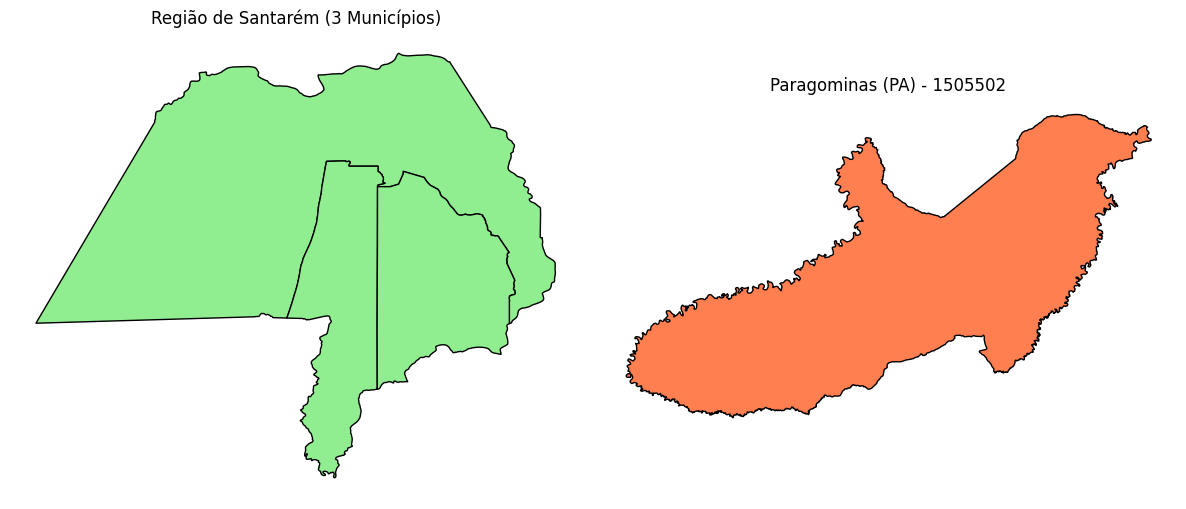


Iniciando download dos rasters do MapBiomas (Cobertura Brasil)...
✅ Arquivo baixado com sucesso: brazil_coverage_2023.tif
✅ Arquivo baixado com sucesso: brazil_coverage_2024.tif

Download concluído.


In [6]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Códigos IBGE
# Santarém (1506807), Belterra (1501402), Mojuí dos Campos (1504752)
codigos_santarem = ['1506807', '1501451', '1504752']
cod_paragominas = '1505502'

print("Obtendo limites municipais diretamente da API do IBGE...")

# Baixa e une os polígonos de Santarém e agregados num único GeoDataFrame
gdf_santarem = obter_shapefiles_municipios(codigos_santarem)
gdf_santarem.loc[:, 'NM_MUN'] = 'Santarém_e_Entorno'

# Baixa SOMENTE o polígono de Paragominas
gdf_paragominas = obter_shapefiles_municipios(cod_paragominas)
gdf_paragominas.loc[:, 'NM_MUN'] = 'Paragominas'

# Visualização rápida para validar as formas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gdf_santarem.plot(ax=axes[0], facecolor="lightgreen", edgecolor="black")
axes[0].set_title("Região de Santarém (3 Municípios)")
axes[0].set_axis_off()

gdf_paragominas.plot(ax=axes[1], facecolor="coral", edgecolor="black")
axes[1].set_title("Paragominas (PA) - 1505502")
axes[1].set_axis_off()
plt.tight_layout()
plt.show()

print("\nIniciando download dos rasters do MapBiomas (Cobertura Brasil)...")
# O script baixará os rasters de 2023 e 2024 para o Brasil todo
download_mapbiomas(
    output_dir="/content/mapbiomas_completo/",
    ano_inicio=2023,
    ano_fim=2024
)

# **Parte 3** - Processo por ID de cada bacia hidrográfica de cada área de estudo (vários polígonos)


🚀 Iniciando processamento: Santarem (Ano 2023)
✅ Raster recortado com sucesso: /content/ROI_STM/mb-brazil-v10-2023.tif

Processo concluído.


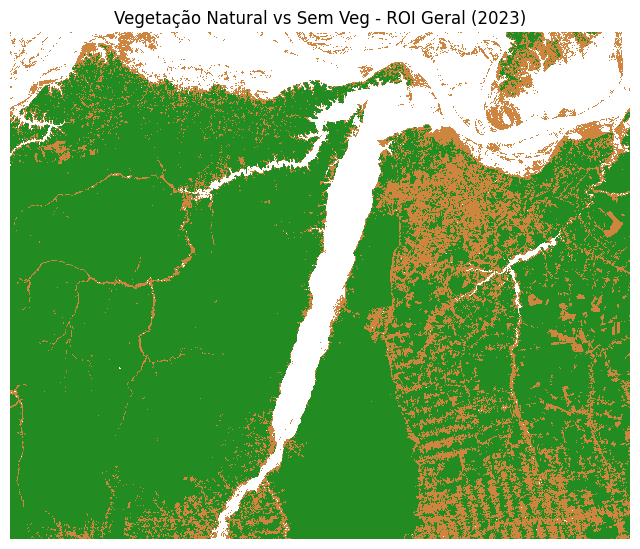

✅ Rasters de vegetação reclassificados salvos em: /content/raster_vegetacao_Geral_Santarem/
Lendo shapefile de hidrografia: /content/drive/MyDrive/Colab Notebooks/PremioMapBiomas/STM_hydroRIVERS_v10.geojson
Reprojetando hidrografia e aplicando buffer de 250.0m...


/tmp/ipykernel_24484/3383018548.py:1070: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydro_buffer_crs.unary_union


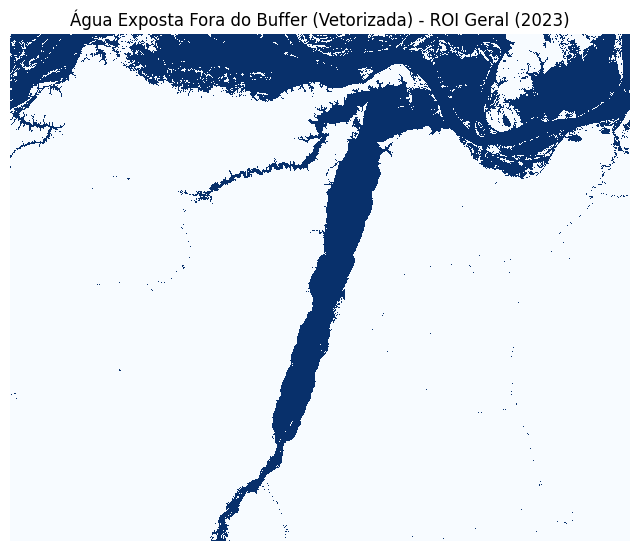

✅ Rasters de água exposta salvos em: /content/raster_agua_Geral_Santarem/

▶ Processando ID_basin = 1
✅ Finalizado ID_basin = 1

▶ Processando ID_basin = 2
✅ Finalizado ID_basin = 2

▶ Processando ID_basin = 3
✅ Finalizado ID_basin = 3

▶ Processando ID_basin = 4
✅ Finalizado ID_basin = 4

▶ Processando ID_basin = 5
✅ Finalizado ID_basin = 5

▶ Processando ID_basin = 6
✅ Finalizado ID_basin = 6

▶ Processando ID_basin = 7
✅ Finalizado ID_basin = 7

▶ Processando ID_basin = 8
✅ Finalizado ID_basin = 8

▶ Processando ID_basin = 9
✅ Finalizado ID_basin = 9

▶ Processando ID_basin = 10
✅ Finalizado ID_basin = 10

▶ Processando ID_basin = 11
✅ Finalizado ID_basin = 11

▶ Processando ID_basin = 12
✅ Finalizado ID_basin = 12

▶ Processando ID_basin = 13
✅ Finalizado ID_basin = 13

▶ Processando ID_basin = 14
✅ Finalizado ID_basin = 14

▶ Processando ID_basin = 15
✅ Finalizado ID_basin = 15

▶ Processando ID_basin = 16
✅ Finalizado ID_basin = 16

▶ Processando ID_basin = 17
✅ Finalizado ID_bas

/tmp/ipykernel_24484/3383018548.py:1221: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydro_buffer_crs.unary_union
/tmp/ipykernel_24484/3383018548.py:1221: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydro_buffer_crs.unary_union
/tmp/ipykernel_24484/3383018548.py:1221: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydro_buffer_crs.unary_union
/tmp/ipykernel_24484/3383018548.py:1221: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydro_buffer_crs.unary_union
/tmp/ipykernel_24484/3383018548.py:1221: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydro_buffer_crs.unary_union
/tmp/ipykernel_24484/3383018548.py:1221: DeprecationWarning: The 


🚀 Iniciando processamento: Paragominas (Ano 2024)
✅ Raster recortado com sucesso: /content/ROI_PGM/mb-brazil-v10-2024.tif

Processo concluído.


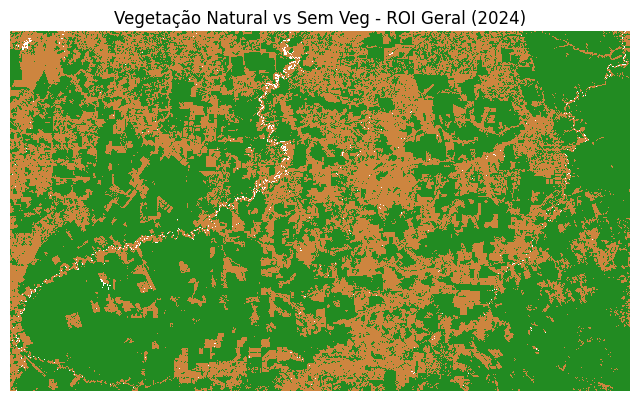

✅ Rasters de vegetação reclassificados salvos em: /content/raster_vegetacao_Geral_Paragominas/
Lendo shapefile de hidrografia: /content/drive/MyDrive/Colab Notebooks/PremioMapBiomas/PGM_hydroRIVERS_v10.geojson
Reprojetando hidrografia e aplicando buffer de 250.0m...


/tmp/ipykernel_24484/3383018548.py:1070: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydro_buffer_crs.unary_union


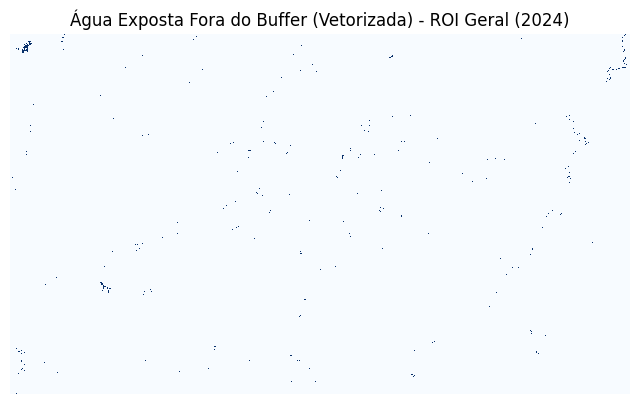

✅ Rasters de água exposta salvos em: /content/raster_agua_Geral_Paragominas/

▶ Processando ID_basin = 1
✅ Finalizado ID_basin = 1

▶ Processando ID_basin = 2
✅ Finalizado ID_basin = 2

▶ Processando ID_basin = 3
✅ Finalizado ID_basin = 3

▶ Processando ID_basin = 4
✅ Finalizado ID_basin = 4

▶ Processando ID_basin = 5
✅ Finalizado ID_basin = 5

▶ Processando ID_basin = 6
✅ Finalizado ID_basin = 6

▶ Processando ID_basin = 7
✅ Finalizado ID_basin = 7

▶ Processando ID_basin = 8
✅ Finalizado ID_basin = 8

▶ Processando ID_basin = 9
✅ Finalizado ID_basin = 9

▶ Processando ID_basin = 10
✅ Finalizado ID_basin = 10

▶ Processando ID_basin = 11
✅ Finalizado ID_basin = 11

▶ Processando ID_basin = 12
✅ Finalizado ID_basin = 12

▶ Processando ID_basin = 13
✅ Finalizado ID_basin = 13

▶ Processando ID_basin = 14
✅ Finalizado ID_basin = 14

▶ Processando ID_basin = 15
✅ Finalizado ID_basin = 15

▶ Processando ID_basin = 16
✅ Finalizado ID_basin = 16

▶ Processando ID_basin = 17
✅ Finalizado ID_

/tmp/ipykernel_24484/3383018548.py:1221: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydro_buffer_crs.unary_union
/tmp/ipykernel_24484/3383018548.py:1221: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydro_buffer_crs.unary_union
/tmp/ipykernel_24484/3383018548.py:1221: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydro_buffer_crs.unary_union
/tmp/ipykernel_24484/3383018548.py:1221: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydro_buffer_crs.unary_union
/tmp/ipykernel_24484/3383018548.py:1221: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  hydro_union = hydro_buffer_crs.unary_union
/tmp/ipykernel_24484/3383018548.py:1221: DeprecationWarning: The 

,Regiao,ID_basin,year,3,6,11,12,15,25,33,...,30,9,20,31,prop_classe_35_perc,prop_classe_4_perc,prop_classe_30_perc,prop_classe_9_perc,prop_classe_20_perc,prop_classe_31_perc
0,Santarem,1,2023,328639,1934,173,135,109463,16,2651,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Santarem,2,2023,6774,473,342,1,8288,30,4400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Santarem,3,2023,491136,16488,1234,110,201439,218,11222,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Santarem,4,2023,21036,768,231,33,16357,37,4161,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Santarem,5,2023,191686,372,49,99,78021,157,499,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


✅ Tabela exportada com sucesso nos formatos CSV e XLSX!
 -> /content/resultados_mapbiomas_STM_PGM.csv
 -> /content/resultados_mapbiomas_STM_PGM.xlsx

✅ Processamento das bacias e exportação de tabelas concluídos!


In [7]:
# =========================================================
# BLOCO COMPLEMENTAR AJUSTADO
# =========================================================

# USO COMPLEMENTAR por polígono

import geopandas as gpd
import pandas as pd

# 1. Definir os parâmetros para cada região de estudo
# Dicionário unificado de processamento
configuracoes_regioes = [
    {
        "nome_regiao": "Santarem",
        "gdf_mun": gdf_santarem, # Usando o polígono isolado que baixamos no Bloco 1
        "ano_alvo": 2023,
        "shape_bacias": "/content/drive/MyDrive/Colab Notebooks/PremioMapBiomas/STM_hydroSHEDS_v10.geojson",
        "shape_hydro": "/content/drive/MyDrive/Colab Notebooks/PremioMapBiomas/STM_hydroRIVERS_v10.geojson",
        "dir_roi": "/content/ROI_STM/",
        "dir_saida_recortes": "/content/recortes_bacias_STM/"
    },
    {
        "nome_regiao": "Paragominas",
        "gdf_mun": gdf_paragominas, # Usando o polígono isolado que baixamos no Bloco 1
        "ano_alvo": 2024,
        "shape_bacias": "/content/drive/MyDrive/Colab Notebooks/PremioMapBiomas/PGM_hydroSHEDS_v10.geojson",
        "shape_hydro": "/content/drive/MyDrive/Colab Notebooks/PremioMapBiomas/PGM_hydroRIVERS_v10.geojson",
        "dir_roi": "/content/ROI_PGM/",
        "dir_saida_recortes": "/content/recortes_bacias_PGM/"
    }
]

resultados_todas_regioes = []

for config in configuracoes_regioes:
    print(f"\n{'='*60}")
    print(f"🚀 Iniciando processamento: {config['nome_regiao']} (Ano {config['ano_alvo']})")
    print(f"{'='*60}")

    # ---------------------------------------------------------
    # PARTE A: Isolar a ROI Geral e Exportar Rasters do Município
    # ---------------------------------------------------------
    # Recortar o raster bruto do Brasil para o quadrante inteiro do Município (ROI)
    recortar_mapbiomas_por_roi(
        gdf_shapefile=config["gdf_mun"],
        input_dir="/content/mapbiomas_completo/",
        output_dir=config["dir_roi"],
        ano_inicio=config["ano_alvo"],
        ano_fim=config["ano_alvo"],
        plotar=False
    )

    # Exportar Rasters de Vegetação / Sem Vegetação (Para o Município Inteiro)
    exportar_e_plotar_raster_vegetacao(
        caminho_imagens=config["dir_roi"],
        output_dir=f"/content/raster_vegetacao_Geral_{config['nome_regiao']}/",
        ano_alvo=config["ano_alvo"],
        plotar=True # Mude para True se quiser ver os mapas das cidades aqui no Colab
    )

    # Exportar Raster de Água Exposta (Para o Município Inteiro)
    exportar_e_plotar_raster_agua_roi(
        caminho_imagens=config["dir_roi"],
        shapefile_hidrografia=config["shape_hydro"],
        output_dir=f"/content/raster_agua_Geral_{config['nome_regiao']}/",
        ano_alvo=config["ano_alvo"],
        buffer_metros=250.0,
        ordem_minima=4,
        tamanho_minimo_agua=9,
        plotar=True # Mude para True se quiser ver as áreas de água aqui no Colab
    )

    # ---------------------------------------------------------
    # PARTE B: Extração Tabular por Bacias Hidrográficas
    # ---------------------------------------------------------
    gdf_bacias = gpd.read_file(config["shape_bacias"])

    gerar_recortes_mapbiomas_por_bacia(
        gdf_base=gdf_bacias,
        id_col="ID_basin",
        input_dir="/content/mapbiomas_completo/",
        output_dir=config["dir_saida_recortes"],
        ano_inicio=config["ano_alvo"],
        ano_fim=config["ano_alvo"],
        plotar=False
    )

    df_base = calcular_frequencia_pixels_por_unidade(
        caminho_imagens=config["dir_saida_recortes"],
        id_col_saida="ID_basin",
        ano_alvo=config["ano_alvo"]
    )

    df_veg = reclassificar_e_calcular_proporcoes(
        df_freq=df_base,
        id_col="ID_basin",
        ano_alvo=config["ano_alvo"]
    )

    df_agua = calcular_agua_exposta_fora_buffer(
        caminho_imagens=config["dir_saida_recortes"],
        shapefile_hidrografia=config["shape_hydro"],
        id_col_saida="ID_basin",
        ano_alvo=config["ano_alvo"],
        buffer_metros=250.0,
        ordem_minima=4,
        tamanho_minimo_agua=9
    )

    # Mesclar e guardar as tabelas geradas para a região
    df_regiao = df_base.merge(df_veg, on=["ID_basin", "year"], how="left")
    df_regiao = df_regiao.merge(df_agua, on=["ID_basin", "year"], how="left")
    df_regiao.insert(0, "Regiao", config["nome_regiao"])

    resultados_todas_regioes.append(df_regiao)

# =========================================================
# 3. EXPORTAÇÃO CONSOLIDADA DA TABELA FINAL (CSV e XLSX)
# =========================================================
df_final_consolidado = pd.concat(resultados_todas_regioes, ignore_index=True)

display(df_final_consolidado.head())

exportar_resultados_finais(
    df_final=df_final_consolidado,
    caminho_base_saida="/content/resultados_mapbiomas_STM_PGM"
)

print("\n✅ Processamento das bacias e exportação de tabelas concluídos!")